# Heart Disease Prediction Using Machine Learning

## Project Overview

Cardiovascular disease is one of the leading causes of death worldwide.
Early and accurate prediction of heart disease can significantly improve
patient outcomes and reduce healthcare costs.

In this project, we build a machine learning model to predict the presence
of heart disease in patients using the Cleveland Heart Disease dataset from
the UCI Machine Learning Repository.

The dataset contains 303 patient records with 13 clinical features such as
age, blood pressure, cholesterol level, and ECG results.

**Goal:** Binary classification — predict whether a patient has heart disease (1) or not (0).

**Dataset Source:** [UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/heart+disease)

## 1. Importing Libraries

We begin by importing all the libraries needed throughout this project.
Each library serves a specific purpose in our machine learning pipeline.

In [1]:
# Data manipulation and analysis
import pandas as pd        # Working with structured data (DataFrames)
import numpy as np         # Numerical operations and array handling

# Data visualization
import matplotlib.pyplot as plt    # Basic plotting
import seaborn as sns              # Statistical visualizations

# Machine learning
from sklearn.model_selection import train_test_split    # Splitting data
from sklearn.preprocessing import StandardScaler        # Feature scaling
from sklearn.linear_model import LogisticRegression     # Our first model
from sklearn.metrics import (
    accuracy_score,         # Overall accuracy
    confusion_matrix,       # True/False positives and negatives
    classification_report   # Precision, recall, F1-score
)

# Display settings
import warnings
warnings.filterwarnings('ignore')    # Suppress non-critical warnings

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Loading the Dataset

We load the Cleveland Heart Disease dataset directly from the UCI repository.
This dataset has no column headers in the raw file, so we define them manually
based on the official documentation.

Missing values in this dataset are represented as `?` — we handle this during loading.

In [2]:
df = pd.read_csv('heart_cleveland_upload.csv')

# Rename columns to match our standard names
df.columns = [
    'age',           # Age of the patient in years
    'sex',           # Sex (1 = male, 0 = female)
    'cp',            # Chest pain type (0–3)
    'trestbps',      # Resting blood pressure (mm Hg)
    'chol',          # Serum cholesterol (mg/dl)
    'fbs',           # Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
    'restecg',       # Resting ECG results (0–2)
    'thalach',       # Maximum heart rate achieved
    'exang',         #Exercise-induced angina (1 = yes, 0 = no)
    'oldpeak',       # ST depression induced by exercise
    'slope',         # Slope of peak exercise ST segment
    'ca',            # Number of major vessels colored by fluoroscopy (0–3)
    'thal',          # Thalassemia type (1 = normal, 2 = fixed defect, 3 = reversible defect)
    'target'         # Diagnosis (0 = no disease, 1–4 = disease present)
]

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 297 rows, 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


## 3. Exploratory Data Analysis (EDA)

Before building any model, we need to understand our data.
EDA helps us answer key questions:
- Are there any missing values?
- What is the distribution of our target variable?
- How are features distributed?
- Are there any obvious patterns or outliers?

In [3]:
# --- Basic Info ---
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== Data Types & Missing Values ===")
print(df.info())

print("\n=== Statistical Summary ===")
df.describe()

=== Dataset Shape ===
Rows: 297, Columns: 14

=== Data Types & Missing Values ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    int64  
 1   sex       297 non-null    int64  
 2   cp        297 non-null    int64  
 3   trestbps  297 non-null    int64  
 4   chol      297 non-null    int64  
 5   fbs       297 non-null    int64  
 6   restecg   297 non-null    int64  
 7   thalach   297 non-null    int64  
 8   exang     297 non-null    int64  
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    int64  
 11  ca        297 non-null    int64  
 12  thal      297 non-null    int64  
 13  target    297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB
None

=== Statistical Summary ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


### 3.1 Target Variable Distribution

We check how balanced our dataset is between patients with and without heart disease.
An imbalanced dataset can mislead the model into ignoring the minority class.

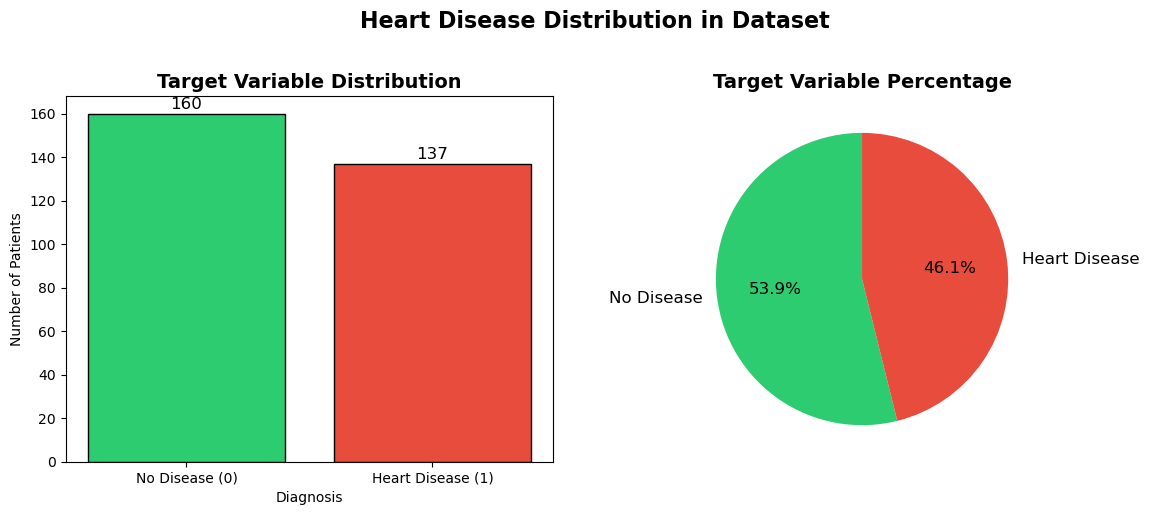


No Disease: 160 patients (53.9%)
Heart Disease: 137 patients (46.1%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Count of each class ---
target_counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Heart Disease (1)'], 
            target_counts.values,
            color=['#2ecc71', '#e74c3c'],
            edgecolor='black')
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].set_xlabel('Diagnosis')

for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=12)

# --- Plot 2: Percentage pie chart ---
axes[1].pie(target_counts.values,
            labels=['No Disease', 'Heart Disease'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Target Variable Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Heart Disease Distribution in Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nNo Disease: {target_counts[0]} patients ({target_counts[0]/len(df)*100:.1f}%)")
print(f"Heart Disease: {target_counts[1]} patients ({target_counts[1]/len(df)*100:.1f}%)")

### 3.2 Feature Distributions by Target

We visualize how key clinical features differ between patients 
with and without heart disease. This helps us identify which 
features are likely to be strong predictors.

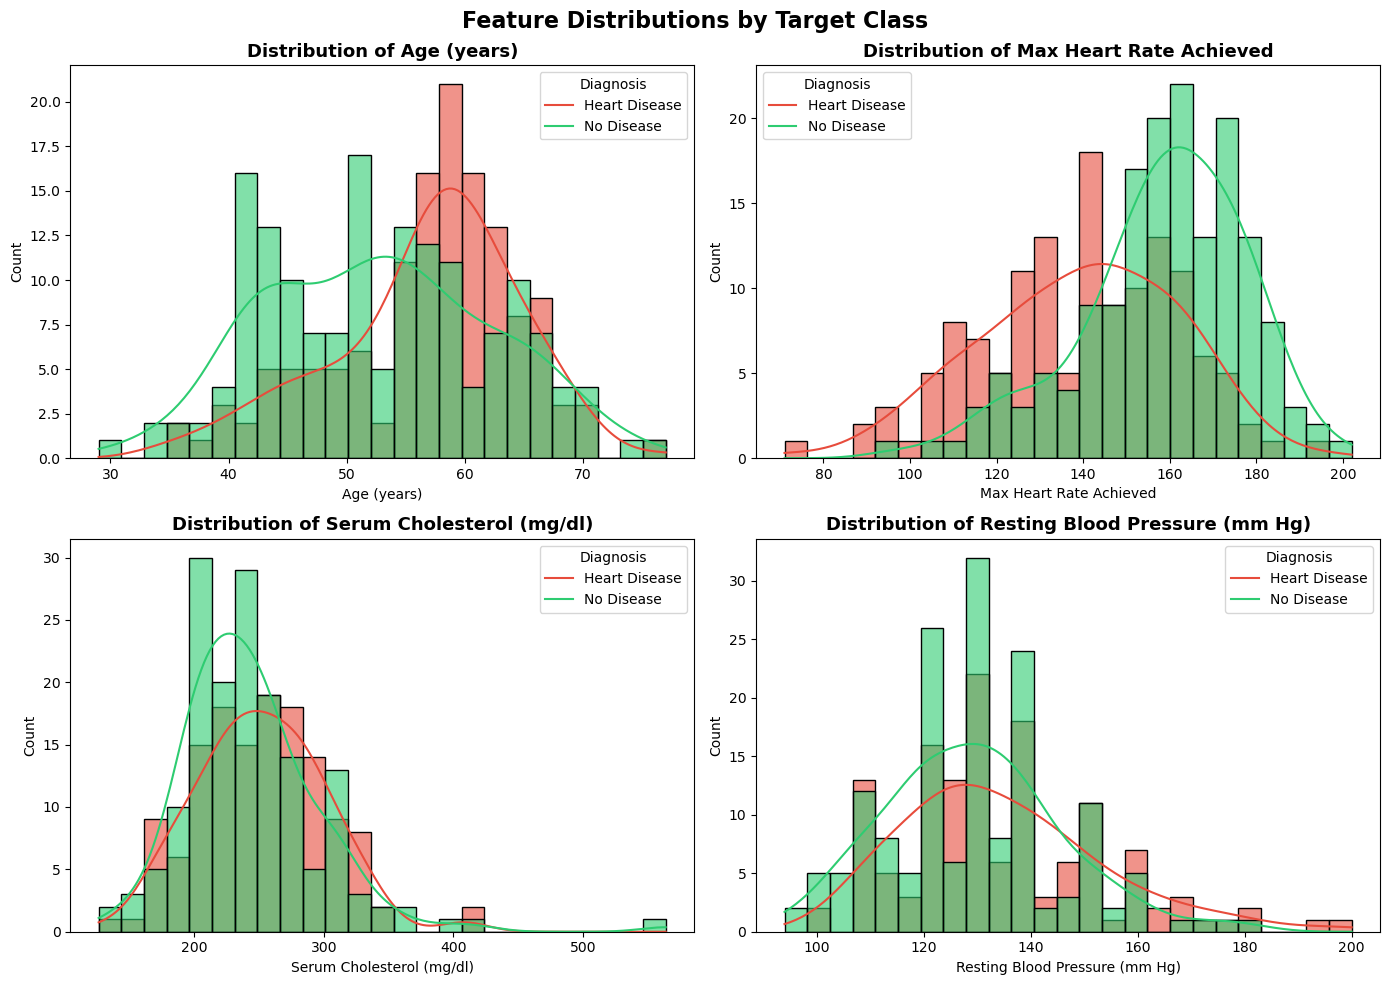

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

features = {
    'age': 'Age (years)',
    'thalach': 'Max Heart Rate Achieved',
    'chol': 'Serum Cholesterol (mg/dl)',
    'trestbps': 'Resting Blood Pressure (mm Hg)'
}

for i, (feature, label) in enumerate(features.items()):
    sns.histplot(data=df, x=feature, hue='target',
                 kde=True, bins=25,
                 palette={0: '#2ecc71', 1: '#e74c3c'},
                 alpha=0.6, ax=axes[i])
    axes[i].set_title(f'Distribution of {label}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Diagnosis', labels=['Heart Disease', 'No Disease'])

plt.suptitle('Feature Distributions by Target Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap

A correlation heatmap shows the linear relationship between all features.
Values close to +1 or -1 indicate strong relationships.
This helps us identify which features are most related to the target,
and whether any features are redundant (multicollinearity).

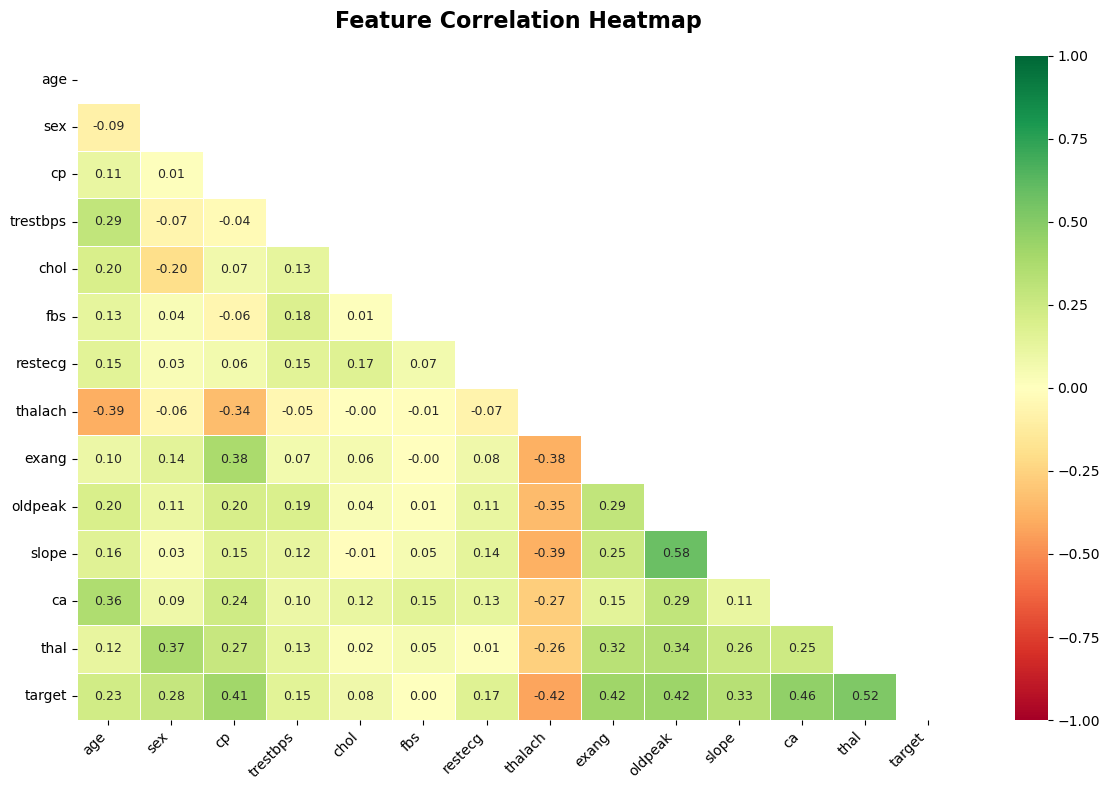

=== Correlation with Target (sorted) ===
target      1.000000
thal        0.520516
ca          0.463189
oldpeak     0.424052
exang       0.421355
cp          0.408945
slope       0.333049
sex         0.278467
age         0.227075
restecg     0.166343
trestbps    0.153490
chol        0.080285
fbs         0.003167
thalach    -0.423817
Name: target, dtype: float64


In [6]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr()

mask = np.zeros_like(correlation_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(correlation_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            annot_kws={'size': 9})

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("=== Correlation with Target (sorted) ===")
print(df.corr()['target'].sort_values(ascending=False))

## 4. Data Preprocessing

Before training a model, we need to prepare the data:
1. Convert target to binary (0 = no disease, 1 = disease)
2. Split data into training and test sets (80/20)
3. Scale features using StandardScaler to normalize value ranges

Important: Scaling is applied AFTER splitting to prevent data leakage.

In [7]:
# Step 1: Convert target to binary
df['target'] = (df['target'] > 0).astype(int)

print("=== Target Distribution After Binarization ===")
print(df['target'].value_counts())

# Step 2: Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Step 3: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n=== Split Results ===")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Step 4: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n=== Scaling Complete ===")
print(f"Feature mean after scaling (first 3): {X_train_scaled.mean(axis=0)[:3].round(4)}")
print(f"Feature std after scaling (first 3): {X_train_scaled.std(axis=0)[:3].round(4)}")

=== Target Distribution After Binarization ===
target
0    160
1    137
Name: count, dtype: int64

Features shape: (297, 13)
Target shape: (297,)

=== Split Results ===
Training set: 237 samples
Test set: 60 samples

=== Scaling Complete ===
Feature mean after scaling (first 3): [-0.  0. -0.]
Feature std after scaling (first 3): [1. 1. 1.]


## 5. Model Training — Logistic Regression

We start with Logistic Regression as our baseline model.
It estimates the probability of heart disease using a linear combination
of features passed through a sigmoid function.

Advantages:
- Fast and interpretable
- Works well on linearly separable data
- Provides probability scores, not just binary predictions

In [8]:
# Initialize and train the model
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model_lr.predict(X_test_scaled)
y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("=== Logistic Regression Results ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

=== Logistic Regression Results ===

Accuracy: 0.9167

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.86      1.00      0.93        32
Heart Disease       1.00      0.82      0.90        28

     accuracy                           0.92        60
    macro avg       0.93      0.91      0.91        60
 weighted avg       0.93      0.92      0.92        60



### 5.1 Confusion Matrix

The confusion matrix breaks down predictions into four categories:
- True Negative (TN): Correctly predicted no disease
- True Positive (TP): Correctly predicted heart disease  
- False Positive (FP): Predicted disease but patient was healthy
- False Negative (FN): Missed disease — most critical error in medical context

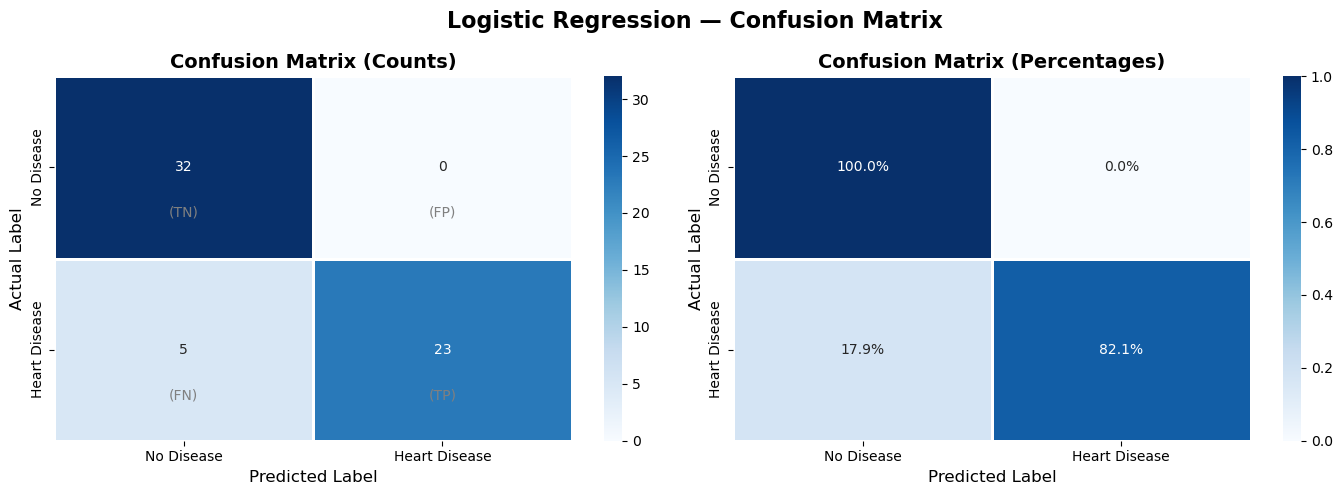

True Negatives  (Healthy → Healthy):  32
True Positives  (Disease → Disease):  23
False Positives (Healthy → Disease):  0 ← unnecessary alarm
False Negatives (Disease → Healthy):  5 ← dangerous miss


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Raw counts ---
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'],
            linewidths=2,
            linecolor='white',
            ax=axes[0])

axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

for i in range(2):
    for j in range(2):
        label = ['TN', 'FP', 'FN', 'TP'][i*2+j]
        axes[0].text(j+0.5, i+0.75, f'({label})',
                    ha='center', va='center',
                    fontsize=10, color='gray')

# --- Plot 2: Normalized percentages ---
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized,
            annot=True,
            fmt='.1%',
            cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'],
            linewidths=2,
            linecolor='white',
            ax=axes[1])

axes[1].set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.suptitle('Logistic Regression — Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Healthy → Healthy):  {tn}")
print(f"True Positives  (Disease → Disease):  {tp}")
print(f"False Positives (Healthy → Disease):  {fp} ← unnecessary alarm")
print(f"False Negatives (Disease → Healthy):  {fn} ← dangerous miss")

## 6. Model Training — Random Forest

Random Forest builds hundreds of decision trees, each trained on a 
random subset of data and features. Final prediction is made by majority vote.

Advantages over Logistic Regression:
- Captures non-linear relationships
- More robust to outliers
- Provides feature importance scores
- Less prone to overfitting than a single decision tree

=== Random Forest Results ===

Accuracy: 0.8333

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.79      0.94      0.86        32
Heart Disease       0.91      0.71      0.80        28

     accuracy                           0.83        60
    macro avg       0.85      0.83      0.83        60
 weighted avg       0.85      0.83      0.83        60



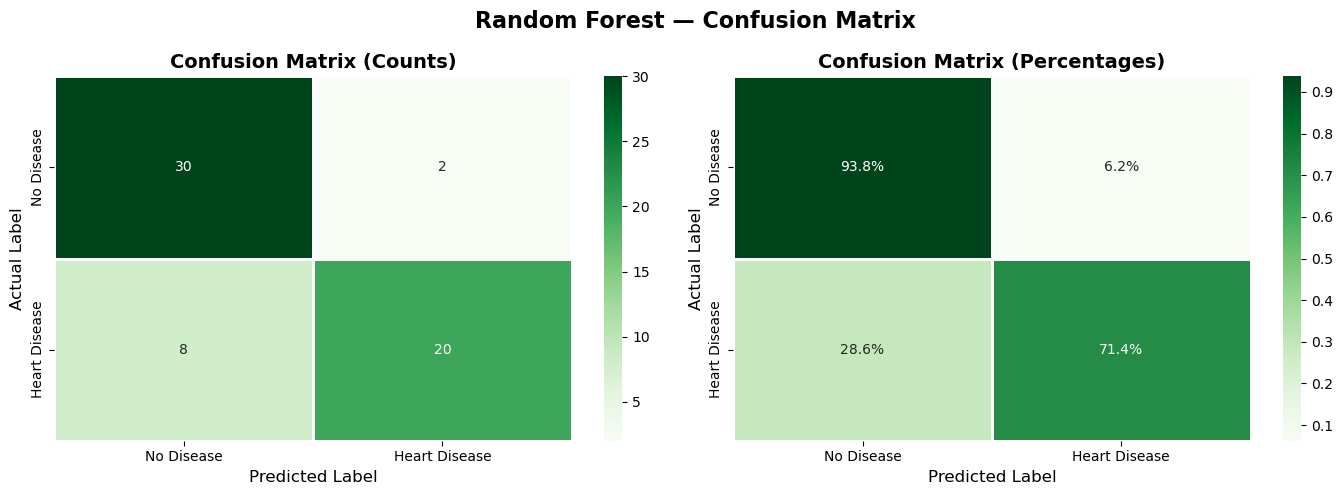

True Negatives  (Healthy → Healthy):  30
True Positives  (Disease → Disease):  20
False Positives (Healthy → Disease):  2 ← unnecessary alarm
False Negatives (Disease → Healthy):  8 ← dangerous miss


In [10]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5,
    min_samples_split=5
)
model_rf.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = model_rf.predict(X_test_scaled)
y_prob_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("=== Random Forest Results ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Heart Disease']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'],
            linewidths=2, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

cm_rf_norm = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_rf_norm, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'],
            linewidths=2, linecolor='white', ax=axes[1])
axes[1].set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.suptitle('Random Forest — Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"True Negatives  (Healthy → Healthy):  {tn}")
print(f"True Positives  (Disease → Disease):  {tp}")
print(f"False Positives (Healthy → Disease):  {fp} ← unnecessary alarm")
print(f"False Negatives (Disease → Healthy):  {fn} ← dangerous miss")

### 6.1 Feature Importance

Random Forest measures feature importance by tracking how much each feature
improves the purity of splits across all trees.

This is critical in Medical AI — clinicians need to understand WHY a model
made a prediction, not just WHAT it predicted. This concept is called
Model Explainability.

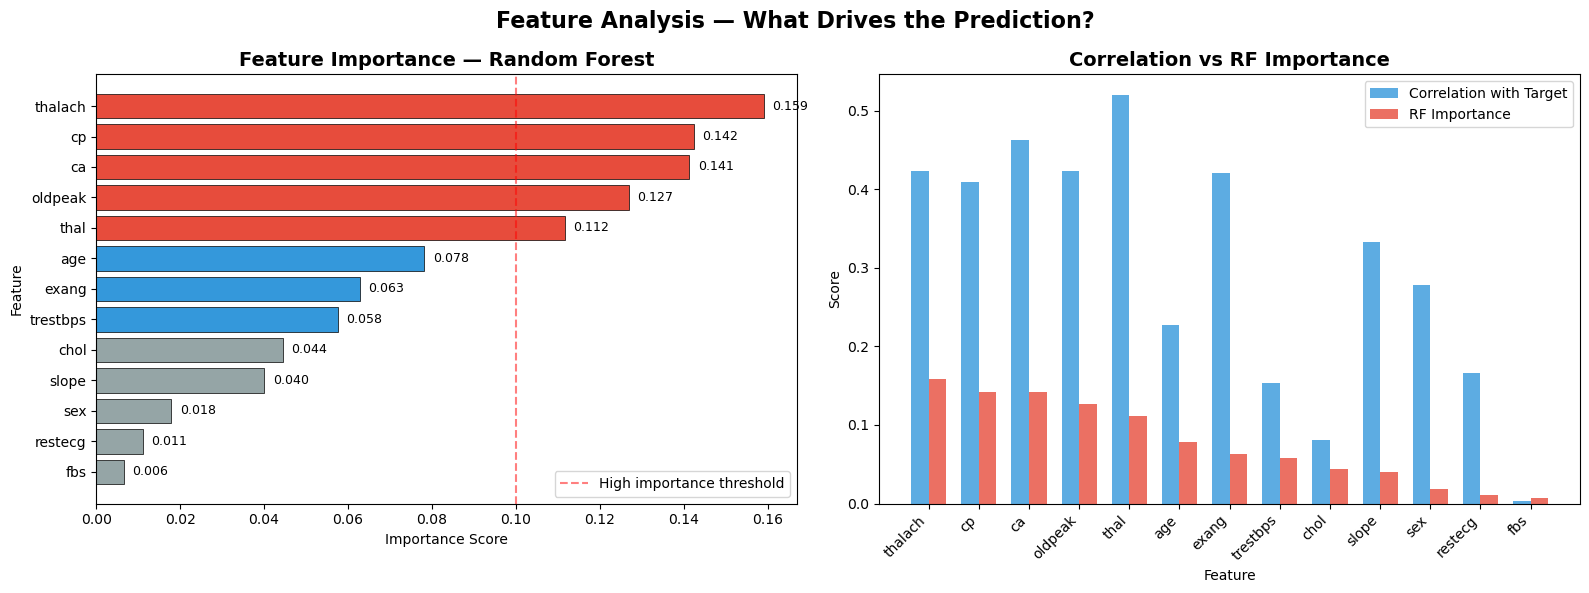

=== Feature Importance Ranking ===
thalach      ███████████████ 0.1590
cp           ██████████████ 0.1424
ca           ██████████████ 0.1414
oldpeak      ████████████ 0.1270
thal         ███████████ 0.1116
age          ███████ 0.0782
exang        ██████ 0.0628
trestbps     █████ 0.0576
chol         ████ 0.0445
slope        ████ 0.0400
sex          █ 0.0179
restecg      █ 0.0111
fbs           0.0065


In [11]:
# Extract feature importance
feature_names = X.columns.tolist()
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Create DataFrame for clean visualization
importance_df = pd.DataFrame({
    'Feature': [feature_names[i] for i in indices],
    'Importance': [importances[i] for i in indices]
})

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Bar chart ---
colors = ['#e74c3c' if imp > 0.1 else '#3498db' if imp > 0.05 else '#95a5a6'
          for imp in importance_df['Importance']]

axes[0].barh(importance_df['Feature'][::-1],
             importance_df['Importance'][::-1],
             color=colors[::-1],
             edgecolor='black',
             linewidth=0.5)

axes[0].set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('Feature')
axes[0].axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='High importance threshold')
axes[0].legend()

for i, (feat, imp) in enumerate(zip(importance_df['Feature'][::-1],
                                     importance_df['Importance'][::-1])):
    axes[0].text(imp + 0.002, i, f'{imp:.3f}', va='center', fontsize=9)

# --- Plot 2: Correlation vs Importance comparison ---
corr_with_target = df.corr()['target'].abs().drop('target')
corr_df = pd.DataFrame({
    'Correlation': corr_with_target,
    'RF Importance': pd.Series(importances, index=feature_names)
})
corr_df = corr_df.sort_values('RF Importance', ascending=False)

x = np.arange(len(corr_df))
width = 0.35

axes[1].bar(x - width/2, corr_df['Correlation'], width,
            label='Correlation with Target', color='#3498db', alpha=0.8)
axes[1].bar(x + width/2, corr_df['RF Importance'], width,
            label='RF Importance', color='#e74c3c', alpha=0.8)

axes[1].set_title('Correlation vs RF Importance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(corr_df.index, rotation=45, ha='right')
axes[1].legend()

plt.suptitle('Feature Analysis — What Drives the Prediction?',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Feature Importance Ranking ===")
for i, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 100)
    print(f"{row['Feature']:12} {bar} {row['Importance']:.4f}")

### 7. Model Comparison — ROC Curve

The ROC (Receiver Operating Characteristic) curve shows model performance
across all possible classification thresholds.

AUC (Area Under the Curve) summarizes the curve in a single number:
- AUC = 1.0 → Perfect model
- AUC = 0.5 → Random guessing
- AUC > 0.8 → Good model for clinical use

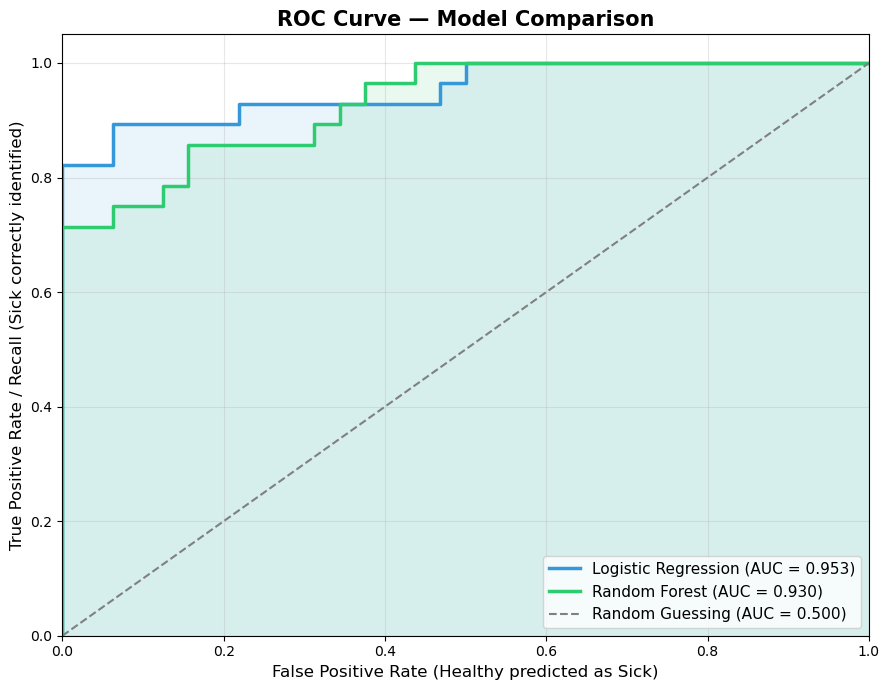

Logistic Regression AUC: 0.9531
Random Forest AUC:       0.9297

Winner: Logistic Regression


In [12]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curves for both models
y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = model_rf.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure(figsize=(9, 7))

plt.plot(fpr_lr, tpr_lr,
         color='#3498db',
         linewidth=2.5,
         label=f'Logistic Regression (AUC = {auc_lr:.3f})')

plt.plot(fpr_rf, tpr_rf,
         color='#2ecc71',
         linewidth=2.5,
         label=f'Random Forest (AUC = {auc_rf:.3f})')

plt.plot([0, 1], [0, 1],
         color='gray',
         linewidth=1.5,
         linestyle='--',
         label='Random Guessing (AUC = 0.500)')

plt.fill_between(fpr_lr, tpr_lr, alpha=0.1, color='#3498db')
plt.fill_between(fpr_rf, tpr_rf, alpha=0.1, color='#2ecc71')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Healthy predicted as Sick)', fontsize=12)
plt.ylabel('True Positive Rate / Recall (Sick correctly identified)', fontsize=12)
plt.title('ROC Curve — Model Comparison', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Random Forest AUC:       {auc_rf:.4f}")
print(f"\nWinner: {'Logistic Regression' if auc_lr > auc_rf else 'Random Forest'}")

## 8. Final Summary & Conclusions

### Project Recap

In this project, we built a machine learning pipeline to predict heart disease
using the Cleveland Heart Disease dataset (297 patients, 13 clinical features).

---

### Key Findings from EDA

| Finding | Detail |
|---|---|
| Dataset balance | 53.9% No Disease / 46.1% Heart Disease — well balanced |
| Strongest predictor | thalach (Max Heart Rate) — clear separation between groups |
| Weakest predictor | fbs (Fasting Blood Sugar) — nearly zero correlation |
| Surprise finding | Cholesterol showed weak predictive power despite common belief |

---

### Most Important Features (from Random Forest)

| Rank | Feature | Importance | Clinical Meaning |
|---|---|---|---|
| 1 | thalach | 0.159 | Max heart rate — diseased hearts pump less efficiently |
| 2 | cp | 0.142 | Chest pain type — direct symptom indicator |
| 3 | ca | 0.141 | Major vessels colored — structural heart damage |
| 4 | oldpeak | 0.127 | ST depression — cardiac stress marker |
| 5 | thal | 0.112 | Thalassemia type — affects oxygen delivery |

---

### Model Comparison

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 91.7% | 83.3% |
| Recall (Disease) | 82.1% | 71.4% |
| Precision (Disease) | 100% | 90.9% |
| AUC | **0.953** | 0.930 |
| False Negatives | 5 | 8 |

**Selected Model: Logistic Regression**

Reason: Higher AUC, better recall on disease class, and zero false positives.
In a medical screening context, missing a sick patient (False Negative)
is far more dangerous than a false alarm (False Positive).

---

### Limitations & Future Work

- **Small dataset:** Only 297 samples. Performance should be validated on larger datasets.
- **Single hospital source:** Cleveland data may not generalize to other populations.
- **Threshold tuning:** Default 0.5 threshold was used. Lowering it could improve recall further.
- **Feature engineering:** Interaction terms between thalach and age could add predictive power.
- **Next models to try:** XGBoost, SVM,